ROBUSTESSE ET ÉVALUATION CLINIQUE
Modèles: ['LIGHTGBM', 'LOGISTICREGRESSION', 'RANDOMFOREST', 'XGBOOST']

🛡️ Robustesse au bruit gaussien


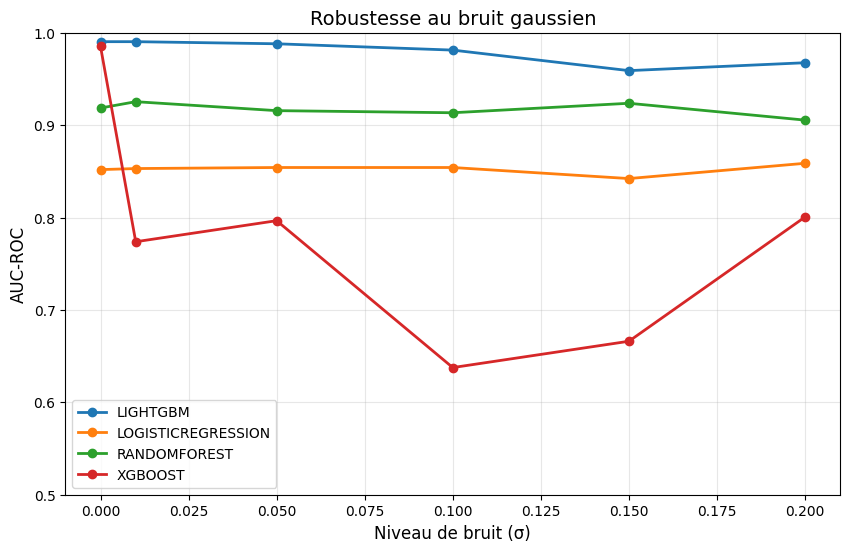


🛡️ Robustesse aux données manquantes


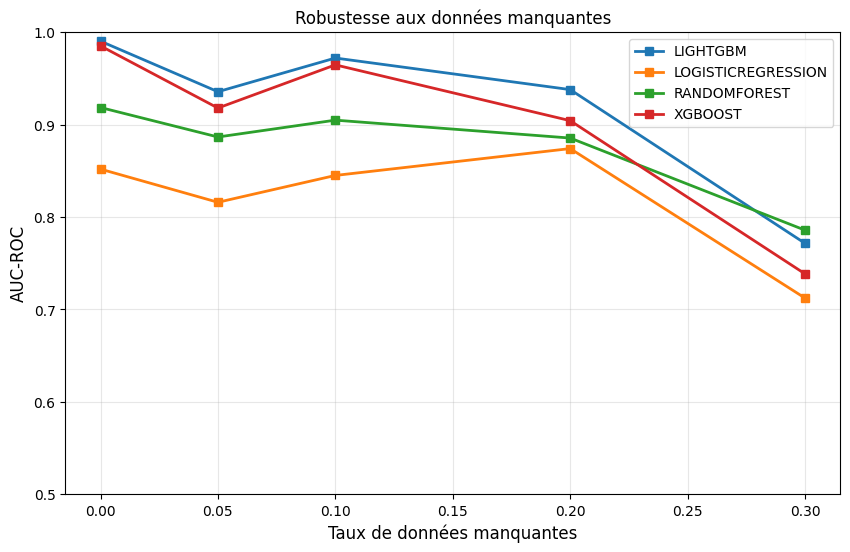


🏥 Métriques cliniques

RAPPORT CLINIQUE
auc_roc        : 0.990
accuracy       : 0.970
sensitivity    : 0.800
specificity    : 0.991
ppv            : 0.923
npv            : 0.975
f1             : 0.857
precision      : 0.923
recall         : 0.800


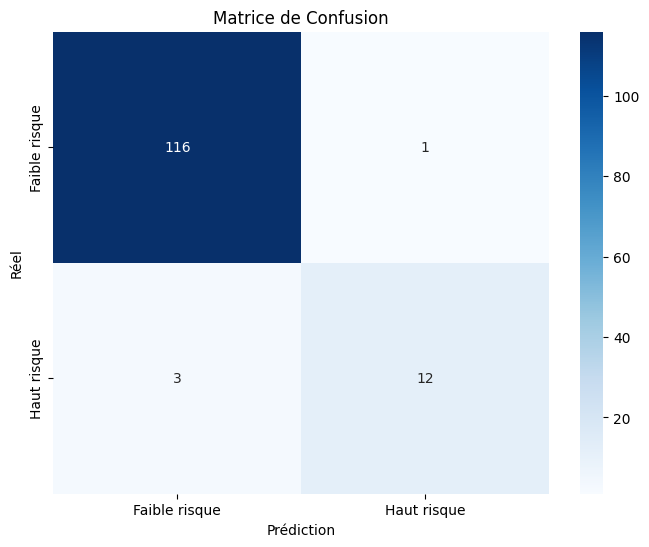

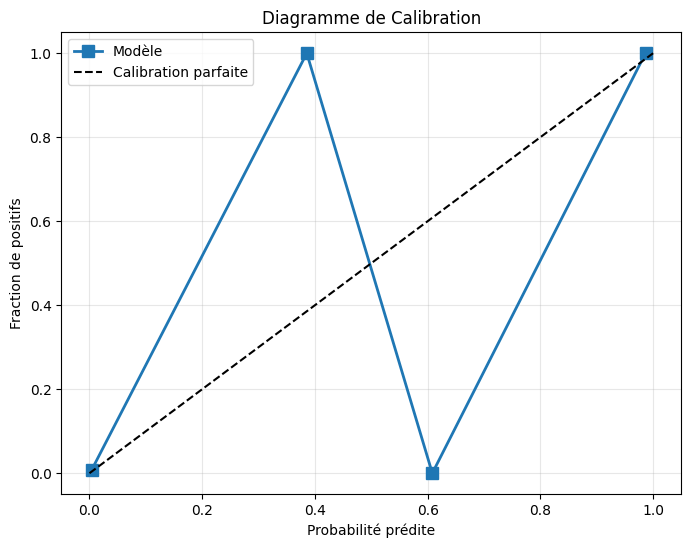


✅ Évaluation clinique terminée!
Résultats sauvegardés dans ..\reports/final_results.json


In [1]:
# Cellule 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
FIGURES_DIR = Path('../figures')
REPORTS_DIR = Path('../reports')

print("="*70)
print("ROBUSTESSE ET ÉVALUATION CLINIQUE")
print("="*70)

# Cellule 2 : Chargement
X_test = np.load(PROCESSED_DIR / 'X_test.npy')
y_test = np.load(PROCESSED_DIR / 'y_test.npy')
feature_names = joblib.load(PROCESSED_DIR / 'selected_features.joblib')

# Charger tous les modèles
models = {}
for f in MODELS_DIR.glob('*_model.joblib'):
    name = f.stem.replace('_model', '').upper()
    models[name] = joblib.load(f)

print(f"Modèles: {list(models.keys())}")

# Cellule 3 : Robustesse au bruit
print("\n🛡️ Robustesse au bruit gaussien")

noise_levels = [0.0, 0.01, 0.05, 0.1, 0.15, 0.2]
noise_results = {name: [] for name in models.keys()}

for noise in noise_levels:
    X_noisy = X_test + np.random.normal(0, noise, X_test.shape) * np.std(X_test, axis=0)
    
    for name, model in models.items():
        y_proba = model.predict_proba(X_noisy)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        noise_results[name].append(auc)

plt.figure(figsize=(10, 6))
for name, aucs in noise_results.items():
    plt.plot(noise_levels, aucs, marker='o', linewidth=2, label=name)

plt.xlabel('Niveau de bruit (σ)', fontsize=12)
plt.ylabel('AUC-ROC', fontsize=12)
plt.title('Robustesse au bruit gaussien', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 1.0)
plt.savefig(FIGURES_DIR / '04_robustness_noise.png', dpi=300, bbox_inches='tight')
plt.show()

# Cellule 4 : Robustesse données manquantes
print("\n🛡️ Robustesse aux données manquantes")

missing_rates = [0.0, 0.05, 0.1, 0.2, 0.3]
missing_results = {name: [] for name in models.keys()}

for rate in missing_rates:
    X_missing = X_test.copy()
    mask = np.random.random(X_missing.shape) < rate
    X_missing[mask] = np.nan
    
    # Imputation médiane
    col_medians = np.nanmedian(X_missing, axis=0)
    for i in range(X_missing.shape[1]):
        X_missing[np.isnan(X_missing[:, i]), i] = col_medians[i]
    
    for name, model in models.items():
        y_proba = model.predict_proba(X_missing)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        missing_results[name].append(auc)

plt.figure(figsize=(10, 6))
for name, aucs in missing_results.items():
    plt.plot(missing_rates, aucs, marker='s', linewidth=2, label=name)

plt.xlabel('Taux de données manquantes', fontsize=12)
plt.ylabel('AUC-ROC', fontsize=12)
plt.title('Robustesse aux données manquantes', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0.5, 1.0)
plt.savefig(FIGURES_DIR / '04_robustness_missing.png', dpi=300, bbox_inches='tight')
plt.show()

# Cellule 5 : Métriques cliniques
print("\n🏥 Métriques cliniques")

best_model = models.get('LIGHTGBM') or list(models.values())[0]
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

metrics = {
    'auc_roc': roc_auc_score(y_test, y_proba),
    'accuracy': accuracy_score(y_test, y_pred),
    'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
    'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
    'ppv': tp / (tp + fp) if (tp + fp) > 0 else 0,
    'npv': tn / (tn + fn) if (tn + fn) > 0 else 0,
    'f1': f1_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred)
}

print(f"\n{'='*50}")
print("RAPPORT CLINIQUE")
print(f"{'='*50}")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.3f}")

# Matrice de confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Faible risque', 'Haut risque'],
            yticklabels=['Faible risque', 'Haut risque'])
plt.xlabel('Prédiction')
plt.ylabel('Réel')
plt.title('Matrice de Confusion')
plt.savefig(FIGURES_DIR / '04_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Cellule 6 : Calibration
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, 's-', linewidth=2, markersize=8, label='Modèle')
plt.plot([0, 1], [0, 1], 'k--', label='Calibration parfaite')
plt.xlabel('Probabilité prédite')
plt.ylabel('Fraction de positifs')
plt.title('Diagramme de Calibration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(FIGURES_DIR / '04_calibration.png', dpi=300, bbox_inches='tight')
plt.show()

# Cellule 7 : Sauvegarde finale
final_results = {
    'model': 'LightGBM',
    'metrics': metrics,
    'robustness_noise_10': noise_results['LIGHTGBM'][3] if 'LIGHTGBM' in noise_results else noise_results[list(noise_results.keys())[0]][3],
    'robustness_missing_20': missing_results['LIGHTGBM'][3] if 'LIGHTGBM' in missing_results else missing_results[list(missing_results.keys())[0]][3]
}

pd.Series(final_results).to_json(REPORTS_DIR / 'final_results.json')

print("\n✅ Évaluation clinique terminée!")
print(f"Résultats sauvegardés dans {REPORTS_DIR}/final_results.json")